In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

df = pd.read_csv("Bank_Customer_Churn_Prediction.csv")

print("=== POINT 1: BI CONTEXT ESTABLISHED ===")
print(f"Dataset successfully loaded. Total Records: {len(df):,}")

=== POINT 1: BI CONTEXT ESTABLISHED ===
Dataset successfully loaded. Total Records: 10,000


In [28]:
import pandas as pd

file_path = 'Bank_Customer_Churn_Prediction.csv'
df = pd.read_csv(file_path)

print("=== POINT 2: DATA COLLECTION AUDIT ===")
print(f"Data Source Format : Structured CSV File")
print(f"Total Collected Rows : {df.shape[0]:,}")
print(f"Total Attributes     : {df.shape[1]}")
print("\nAttribute Taxonomy Breakdown:")

categorical_vars = df.select_dtypes(include=['object']).columns.tolist()
numeric_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f" - Numerical Attributes   ({len(numeric_vars)}): {numeric_vars}")
print(f" - Categorical Attributes ({len(categorical_vars)}): {categorical_vars}")

=== POINT 2: DATA COLLECTION AUDIT ===
Data Source Format : Structured CSV File
Total Collected Rows : 10,000
Total Attributes     : 12

Attribute Taxonomy Breakdown:
 - Numerical Attributes   (10): ['customer_id', 'credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']
 - Categorical Attributes (2): ['country', 'gender']


In [29]:
import pandas as pd

df = pd.read_csv('Bank_Customer_Churn_Prediction.csv')

total_customers = len(df)
total_churned = df['churn'].sum()
baseline_churn_rate = (total_churned / total_customers) * 100
total_balance_at_risk = df[df['churn'] == 1]['balance'].sum()

print("=== POINT 3: BUSINESS PROBLEM DEFINITION ===")
print(f"Problem Statement      : High Customer Attrition & Capital Flight")
print(f"Total Customer Base    : {total_customers:,} account holders")
print(f"Churned Customers      : {total_churned:,} exited accounts")
print(f"Baseline Churn Rate    : {baseline_churn_rate:.2f}%")
print(f"Total Capital Flight   : ${total_balance_at_risk:,.2f} USD")

=== POINT 3: BUSINESS PROBLEM DEFINITION ===
Problem Statement      : High Customer Attrition & Capital Flight
Total Customer Base    : 10,000 account holders
Churned Customers      : 2,037 exited accounts
Baseline Churn Rate    : 20.37%
Total Capital Flight   : $185,588,094.63 USD


In [30]:
import pandas as pd

df = pd.read_csv('Bank_Customer_Churn_Prediction.csv')

fact_customer_metrics = df[['customer_id', 'credit_score', 'balance', 
                            'estimated_salary', 'tenure', 'churn']].copy()

dim_demographics = df[['customer_id', 'country', 'gender', 'age']].copy()

dim_product_engagement = df[['customer_id', 'products_number', 
                             'credit_card', 'active_member']].copy()

print("=== POINT 4: DATA STORAGE & SCHEMA ORGANIZATION ===")
print(f"Fact Table ('Fact_Customer_Metrics')   : {fact_customer_metrics.shape[0]} rows x {fact_customer_metrics.shape[1]} cols")
print(f"Dimension 1 ('Dim_Demographics')       : {dim_demographics.shape[0]} rows x {dim_demographics.shape[1]} cols")
print(f"Dimension 2 ('Dim_Product_Engagement') : {dim_product_engagement.shape[0]} rows x {dim_product_engagement.shape[1]} cols")

print("\nFact Table Preview:")
print(fact_customer_metrics.head(3))

=== POINT 4: DATA STORAGE & SCHEMA ORGANIZATION ===
Fact Table ('Fact_Customer_Metrics')   : 10000 rows x 6 cols
Dimension 1 ('Dim_Demographics')       : 10000 rows x 4 cols
Dimension 2 ('Dim_Product_Engagement') : 10000 rows x 4 cols

Fact Table Preview:
   customer_id  credit_score   balance  estimated_salary  tenure  churn
0     15634602           619      0.00         101348.88       2      1
1     15647311           608  83807.86         112542.58       1      0
2     15619304           502 159660.80         113931.57       8      1


In [31]:
import pandas as pd

df = pd.read_csv('Bank_Customer_Churn_Prediction.csv')

print("=== POINT 5: DATA UNDERSTANDING & INSPECTION ===")

print(f"Dataset Shape: {df.shape[0]} Rows, {df.shape[1]} Columns\n")
print("Columns List:", df.columns.tolist())

print("\n--- Data Types & Missing Values Audit ---")
print(df.info())

print("\n--- Quality Diagnostic ---")
print("Missing Values per Column:\n", df.isnull().sum())
print("Duplicate Customer Records:", df['customer_id'].duplicated().sum())

print("\n--- Descriptive Summary (df.describe()) ---")
print(df.describe().T[['mean', 'std', 'min', '50%', 'max']])

print("\n--- Categorical Distributions ---")
print("Countries Represented:\n", df['country'].value_counts())
print("\nGender Breakdown:\n", df['gender'].value_counts())

=== POINT 5: DATA UNDERSTANDING & INSPECTION ===
Dataset Shape: 10000 Rows, 12 Columns

Columns List: ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

--- Data Types & Missing Values Audit ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary 

In [32]:
import pandas as pd

df = pd.read_csv('Bank_Customer_Churn_Prediction.csv')

print("=== POINT 6: DATA CLEANING ===")

initial_count = len(df)
df = df.drop_duplicates(subset=['customer_id'])
print(f"Removed {initial_count - len(df)} duplicate records.")

string_columns = ['country', 'gender']
for col in string_columns:
    df[col] = df[col].astype(str).str.strip().str.title()

df['customer_id'] = df['customer_id'].astype(str)
df['credit_card'] = df['credit_card'].astype(int)
df['active_member'] = df['active_member'].astype(int)
df['churn'] = df['churn'].astype(int)

invalid_balances = (df['balance'] < 0).sum()
invalid_salaries = (df['estimated_salary'] < 0).sum()
print(f"Invalid Negative Balances: {invalid_balances}")
print(f"Invalid Negative Salaries: {invalid_salaries}")

print("\n--- Cleaned Data Audit ---")
print("Null values count:\n", df.isnull().sum().to_dict())
print("Data types after cleaning:\n", df.dtypes[['customer_id', 'country', 'gender', 'churn']])

=== POINT 6: DATA CLEANING ===
Removed 0 duplicate records.
Invalid Negative Balances: 0
Invalid Negative Salaries: 0

--- Cleaned Data Audit ---
Null values count:
 {'customer_id': 0, 'credit_score': 0, 'country': 0, 'gender': 0, 'age': 0, 'tenure': 0, 'balance': 0, 'products_number': 0, 'credit_card': 0, 'active_member': 0, 'estimated_salary': 0, 'churn': 0}
Data types after cleaning:
 customer_id    object
country        object
gender         object
churn           int64
dtype: object


In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv('Bank_Customer_Churn_Prediction.csv')

df['customer_id'] = df['customer_id'].astype(str)

print("=== POINT 7: DATA TRANSFORMATION ===")

df['churn_label'] = df['churn'].map({0: 'Retained', 1: 'Exited'})
df['activity_label'] = df['active_member'].map({0: 'Inactive Member', 1: 'Active Member'})
df['has_credit_card'] = df['credit_card'].map({0: 'No Credit Card', 1: 'Has Credit Card'})

age_bins = [0, 30, 40, 50, 60, 100]
age_labels = ['<30', '30-39', '40-49', '50-59', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

balance_bins = [-1, 0, 50000, 100000, 150000, np.inf]
balance_labels = ['Zero Balance', 'Low (<$50k)', 'Medium ($50k-$100k)', 'High ($100k-$150k)', 'Very High (>$150k)']
df['balance_tier'] = pd.cut(df['balance'], bins=balance_bins, labels=balance_labels)

credit_bins = [0, 580, 670, 740, 850]
credit_labels = ['Poor (<580)', 'Fair (580-669)', 'Good (670-739)', 'Excellent (740+)']
df['credit_tier'] = pd.cut(df['credit_score'], bins=credit_bins, labels=credit_labels)

df['product_category'] = df['products_number'].map({
    1: '1 Product', 2: '2 Products', 3: '3 Products', 4: '4 Products'
})

df['balance_lost'] = np.where(df['churn'] == 1, df['balance'], 0.0)
df['balance_to_salary_ratio'] = np.round(df['balance'] / np.where(df['estimated_salary'] == 0, 1, df['estimated_salary']), 4)

df.to_csv('Transformed_Bank_Customer_Churn.csv', index=False)

print("Data transformation complete. Transformed file saved as 'Transformed_Bank_Customer_Churn.csv'.")
print("\nPreview of New Transformed Columns:")
print(df[['customer_id', 'churn_label', 'age_group', 'balance_tier', 'credit_tier', 'balance_lost']].head(5))

=== POINT 7: DATA TRANSFORMATION ===
Data transformation complete. Transformed file saved as 'Transformed_Bank_Customer_Churn.csv'.

Preview of New Transformed Columns:
  customer_id churn_label age_group         balance_tier       credit_tier  \
0    15634602      Exited     40-49         Zero Balance    Fair (580-669)   
1    15647311    Retained     40-49  Medium ($50k-$100k)    Fair (580-669)   
2    15619304      Exited     40-49   Very High (>$150k)       Poor (<580)   
3    15701354    Retained     30-39         Zero Balance    Good (670-739)   
4    15737888    Retained     40-49   High ($100k-$150k)  Excellent (740+)   

   balance_lost  
0          0.00  
1          0.00  
2     159660.80  
3          0.00  
4          0.00  


In [34]:
import pandas as pd

df = pd.read_csv('Transformed_Bank_Customer_Churn.csv')

print("=== POINT 8: EXPLORATORY DATA ANALYSIS (EDA) ===\n")

print("--- 1. UNIVARIATE ANALYSIS ---")
print("Overall Churn Distribution (%):")
print(df['churn_label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nCustomer Distribution by Country (%):")
print(df['country'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n--- 2. BIVARIATE ANALYSIS ---")
print("Churn Rate by Country:")
country_bivariate = df.groupby('country')['churn'].mean().mul(100).round(2).astype(str) + '%'
print(country_bivariate)

print("\nChurn Rate by Product Category:")
product_bivariate = df.groupby('product_category')['churn'].mean().mul(100).round(2).astype(str) + '%'
print(product_bivariate)

print("\n--- 3. MULTIVARIATE ANALYSIS ---")
print("Churn Rate (%) by Country, Age Group, and Activity Status:")
multivariate_pivot = df.pivot_table(
    index=['country', 'age_group'],
    columns='activity_label',
    values='churn',
    aggfunc=lambda x: round(x.mean() * 100, 2)
)
print(multivariate_pivot)

=== POINT 8: EXPLORATORY DATA ANALYSIS (EDA) ===

--- 1. UNIVARIATE ANALYSIS ---
Overall Churn Distribution (%):
churn_label
Retained    79.63%
Exited      20.37%
Name: proportion, dtype: object

Customer Distribution by Country (%):
country
France     50.14%
Germany    25.09%
Spain      24.77%
Name: proportion, dtype: object

--- 2. BIVARIATE ANALYSIS ---
Churn Rate by Country:
country
France     16.15%
Germany    32.44%
Spain      16.67%
Name: churn, dtype: object

Churn Rate by Product Category:
product_category
1 Product     27.71%
2 Products     7.58%
3 Products    82.71%
4 Products    100.0%
Name: churn, dtype: object

--- 3. MULTIVARIATE ANALYSIS ---
Churn Rate (%) by Country, Age Group, and Activity Status:
activity_label     Active Member  Inactive Member
country age_group                                
France  30-39               6.04            10.17
        40-49              18.92            31.54
        50-59              34.35            77.63
        60+              

In [35]:
import pandas as pd
import numpy as np

df = pd.read_csv('Transformed_Bank_Customer_Churn.csv')

print("=== POINT 9: STATISTICAL ANALYSIS ===\n")

numeric_features = ['age', 'balance', 'credit_score', 'tenure', 'products_number', 'estimated_salary']

print("--- 1. COMPARATIVE DESCRIPTIVE STATISTICS ---")
stats_comparison = df.groupby('churn_label')[numeric_features].agg(
    ['mean', 'std', 'median', lambda x: x.quantile(0.75) - x.quantile(0.25)]
).rename(columns={'<lambda_0>': 'IQR'}).T

print(stats_comparison.round(2))

print("\n--- 2. CORRELATION WITH CHURN TARGET ---")
numeric_df = df[['churn', 'age', 'balance', 'active_member', 'products_number', 'credit_score', 'tenure', 'estimated_salary']]
correlations = numeric_df.corr()['churn'].sort_values(ascending=False)

print("Pearson Correlation Coefficients (r) relative to Churn:")
for feature, corr_val in correlations.items():
    if feature != 'churn':
        print(f" - {feature:<20}: {corr_val:+.4f}")

=== POINT 9: STATISTICAL ANALYSIS ===

--- 1. COMPARATIVE DESCRIPTIVE STATISTICS ---
churn_label                Exited  Retained
age              mean       44.84     37.41
                 std         9.76     10.13
                 median     45.00     36.00
                 IQR        13.00     10.00
balance          mean    91108.54  72745.30
                 std     58360.79  62848.04
                 median 109349.29  92072.68
                 IQR     93093.31 126410.28
credit_score     mean      645.35    651.85
                 std       100.32     95.65
                 median    646.00    653.00
                 IQR       138.00    133.00
tenure           mean        4.93      5.03
                 std         2.94      2.88
                 median      5.00      5.00
                 IQR         6.00      4.00
products_number  mean        1.48      1.54
                 std         0.80      0.51
                 median      1.00      2.00
                 IQR         1.00  

In [36]:
import pandas as pd

df = pd.read_csv('Transformed_Bank_Customer_Churn.csv')

print("=== POINT 10: BUSINESS KPI ANALYSIS ===\n")

total_customers = len(df)
churned_customers = df['churn'].sum()
retained_customers = total_customers - churned_customers
churn_rate = (churned_customers / total_customers) * 100
retention_rate = 100.0 - churn_rate
active_members = df['active_member'].sum()
active_member_ratio = (active_members / total_customers) * 100

total_portfolio_balance = df['balance'].sum()
total_balance_lost = df['balance_lost'].sum()
avg_balance_churned = df[df['churn'] == 1]['balance'].mean()
financial_attrition_ratio = (total_balance_lost / total_portfolio_balance) * 100

kpi_data = {
    'KPI Category': [
        'Customer', 'Customer', 'Customer', 'Customer', 'Customer',
        'Financial', 'Financial', 'Financial', 'Financial'
    ],
    'Metric Name': [
        'Total Customer Base',
        'Retained Customers Count',
        'Churned Customers Count',
        'Customer Churn Rate (%)',
        'Active Member Ratio (%)',
        'Total Portfolio Capital ($)',
        'Total Balance Flight / Lost ($)',
        'Average Balance Lost per Churned Customer ($)',
        'Financial Attrition Ratio (%)'
    ],
    'Value': [
        f"{total_customers:,}",
        f"{retained_customers:,}",
        f"{churned_customers:,}",
        f"{churn_rate:.2f}%",
        f"{active_member_ratio:.2f}%",
        f"${total_portfolio_balance:,.2f}",
        f"${total_balance_lost:,.2f}",
        f"${avg_balance_churned:,.2f}",
        f"{financial_attrition_ratio:.2f}%"
    ]
}

kpi_df = pd.DataFrame(kpi_data)
print(kpi_df.to_string(index=False))

=== POINT 10: BUSINESS KPI ANALYSIS ===

KPI Category                                   Metric Name           Value
    Customer                           Total Customer Base          10,000
    Customer                      Retained Customers Count           7,963
    Customer                       Churned Customers Count           2,037
    Customer                       Customer Churn Rate (%)          20.37%
    Customer                       Active Member Ratio (%)          51.51%
   Financial                   Total Portfolio Capital ($) $764,858,892.88
   Financial               Total Balance Flight / Lost ($) $185,588,094.63
   Financial Average Balance Lost per Churned Customer ($)      $91,108.54
   Financial                 Financial Attrition Ratio (%)          24.26%


In [37]:
import pandas as pd

df = pd.read_csv('Transformed_Bank_Customer_Churn.csv')

print("=== POINT 11: DATA SEGMENTATION AND GROUPING ===\n")

def get_segmentation_summary(df, group_col):
    return df.groupby(group_col, observed=False).agg(
        Total_Customers=('customer_id', 'count'),
        Churned_Customers=('churn', 'sum'),
        Churn_Rate_Pct=('churn', lambda x: round(x.mean() * 100, 2)),
        Capital_Lost_USD=('balance_lost', lambda x: round(x.sum(), 2))
    ).reset_index()

print("--- 1. GEOGRAPHIC BRANCH SEGMENTATION ---")
geo_seg = get_segmentation_summary(df, 'country')
print(geo_seg.to_string(index=False))

print("\n--- 2. PRODUCT HOLDINGS SEGMENTATION ---")
prod_seg = get_segmentation_summary(df, 'product_category')
print(prod_seg.to_string(index=False))

print("\n--- 3. DEMOGRAPHIC AGE COHORT SEGMENTATION ---")
age_seg = get_segmentation_summary(df, 'age_group')
print(age_seg.to_string(index=False))

print("\n--- 4. ACCOUNT WEALTH TIER SEGMENTATION ---")
wealth_seg = get_segmentation_summary(df, 'balance_tier')
print(wealth_seg.to_string(index=False))

=== POINT 11: DATA SEGMENTATION AND GROUPING ===

--- 1. GEOGRAPHIC BRANCH SEGMENTATION ---
country  Total_Customers  Churned_Customers  Churn_Rate_Pct  Capital_Lost_USD
 France             5014                810           16.15       57666164.54
Germany             2509                814           32.44       97973915.53
  Spain             2477                413           16.67       29948014.56

--- 2. PRODUCT HOLDINGS SEGMENTATION ---
product_category  Total_Customers  Churned_Customers  Churn_Rate_Pct  Capital_Lost_USD
       1 Product             5084               1409           27.71      129668607.08
      2 Products             4590                348            7.58       31407820.29
      3 Products              266                220           82.71       18887679.16
      4 Products               60                 60          100.00        5623988.10

--- 3. DEMOGRAPHIC AGE COHORT SEGMENTATION ---
age_group  Total_Customers  Churned_Customers  Churn_Rate_Pct  Capital_

=== POINT 12: DATA VISUALIZATION ===


C:\Users\DINKA\AppData\Local\Temp\ipykernel_14528\1139348024.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot1 = sns.barplot(data=country_metrics, x='country', y='churn_rate', ax=ax1, palette='Blues_r')
C:\Users\DINKA\AppData\Local\Temp\ipykernel_14528\1139348024.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot2 = sns.barplot(data=product_metrics, x='product_category', y='churn_rate', ax=ax2, palette='Oranges_r')
C:\Users\DINKA\AppData\Local\Temp\ipykernel_14528\1139348024.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot4 = sns.barplot(data=

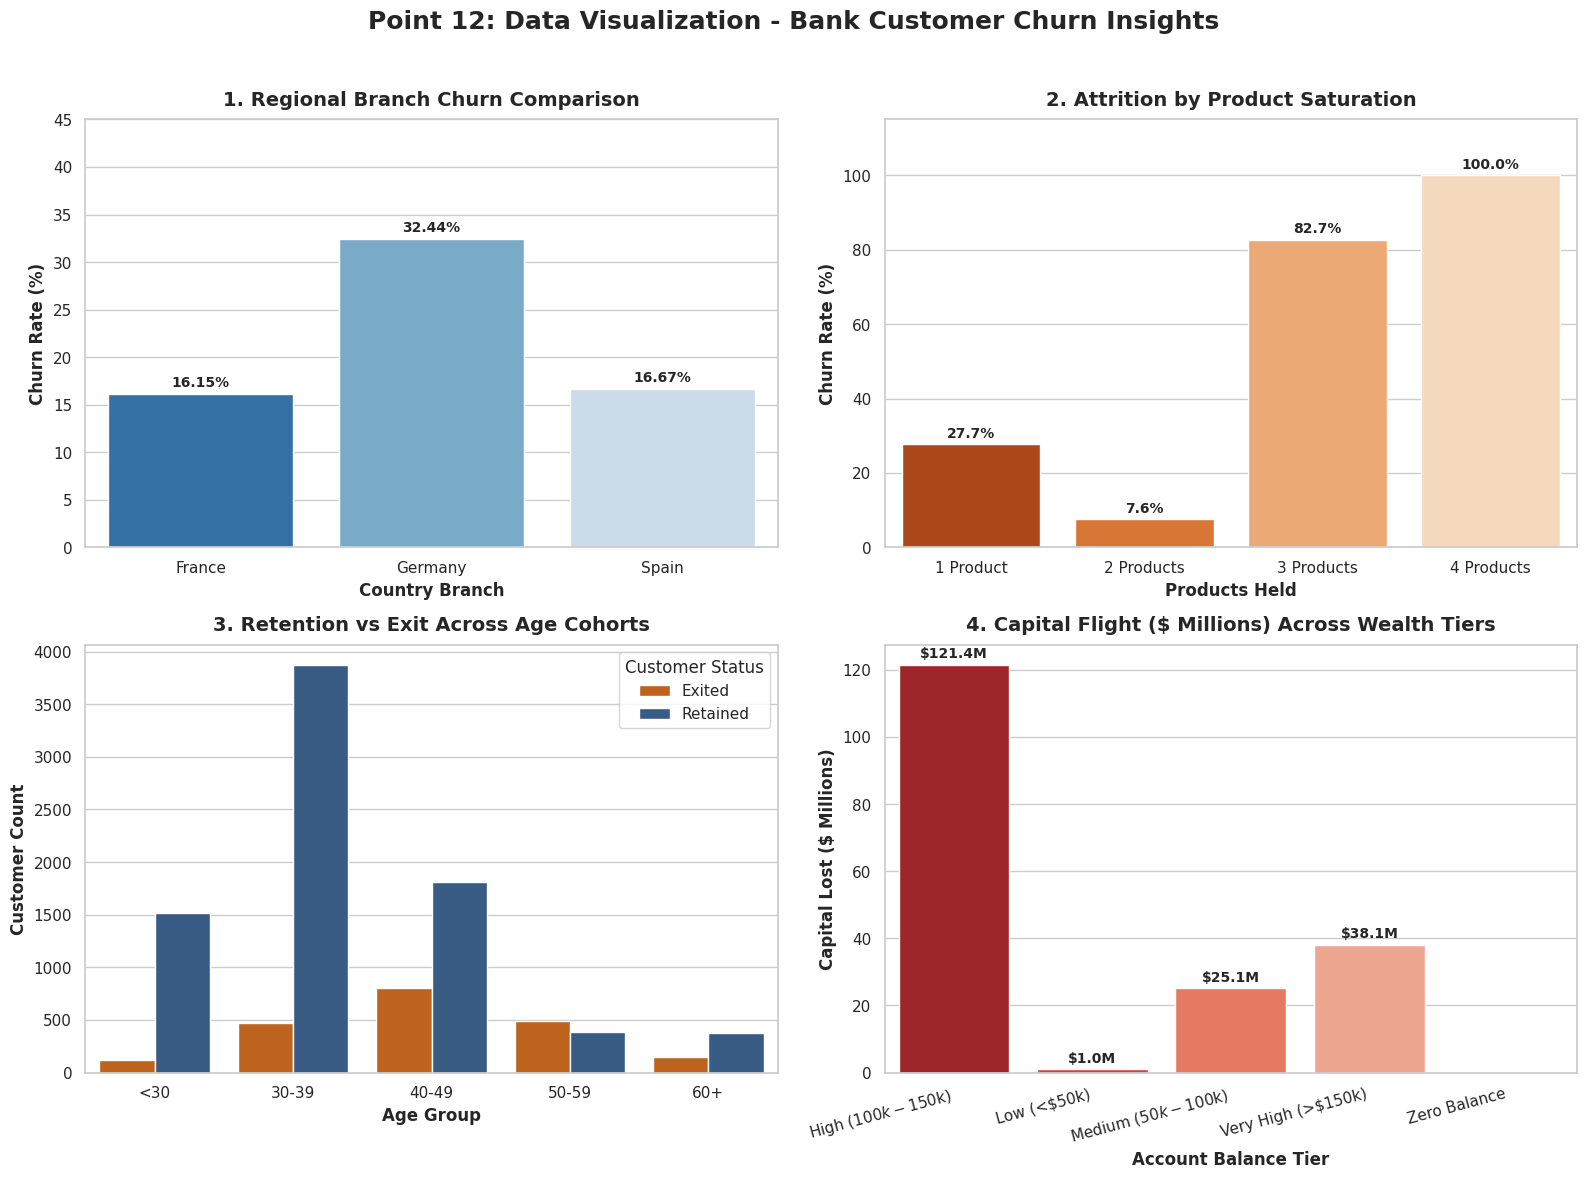

Data visualizations successfully rendered and saved as 'Point12_BI_Visualizations.png'.


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})

df = pd.read_csv('Transformed_Bank_Customer_Churn.csv')

print("=== POINT 12: DATA VISUALIZATION ===")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Point 12: Data Visualization - Bank Customer Churn Insights', fontsize=18, fontweight='bold', y=0.98)

country_metrics = df.groupby('country').agg(
    churn_rate=('churn', lambda x: x.mean() * 100)
).reset_index()

ax1 = axes[0, 0]
barplot1 = sns.barplot(data=country_metrics, x='country', y='churn_rate', ax=ax1, palette='Blues_r')
ax1.set_title('1. Regional Branch Churn Comparison', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Country Branch', fontweight='bold')
ax1.set_ylabel('Churn Rate (%)', fontweight='bold')
ax1.set_ylim(0, 45)

for p in barplot1.patches:
    height = p.get_height()
    ax1.annotate(f'{height:.2f}%',
                 (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3),
                 textcoords='offset points')

product_metrics = df.groupby('product_category', observed=False).agg(
    churn_rate=('churn', lambda x: x.mean() * 100)
).reset_index()

ax2 = axes[0, 1]
barplot2 = sns.barplot(data=product_metrics, x='product_category', y='churn_rate', ax=ax2, palette='Oranges_r')
ax2.set_title('2. Attrition by Product Saturation', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Products Held', fontweight='bold')
ax2.set_ylabel('Churn Rate (%)', fontweight='bold')
ax2.set_ylim(0, 115)

for p in barplot2.patches:
    height = p.get_height()
    ax2.annotate(f'{height:.1f}%',
                 (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3),
                 textcoords='offset points')

ax3 = axes[1, 0]
age_order = ['<30', '30-39', '40-49', '50-59', '60+']
sns.countplot(data=df, x='age_group', hue='churn_label', order=age_order, ax=ax3, palette={'Retained': '#2b5c8f', 'Exited': '#d95f02'})
ax3.set_title('3. Retention vs Exit Across Age Cohorts', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Age Group', fontweight='bold')
ax3.set_ylabel('Customer Count', fontweight='bold')
ax3.legend(title='Customer Status', frameon=True)

balance_metrics = df.groupby('balance_tier', observed=False).agg(
    total_lost=('balance_lost', lambda x: x.sum() / 1e6)
).reset_index()

ax4 = axes[1, 1]
barplot4 = sns.barplot(data=balance_metrics, x='balance_tier', y='total_lost', ax=ax4, palette='Reds_r')
ax4.set_title('4. Capital Flight ($ Millions) Across Wealth Tiers', fontsize=14, fontweight='bold', pad=10)
ax4.set_xlabel('Account Balance Tier', fontweight='bold')
ax4.set_ylabel('Capital Lost ($ Millions)', fontweight='bold')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=15, ha='right')

for p in barplot4.patches:
    height = p.get_height()
    if height > 0:
        ax4.annotate(f'${height:.1f}M',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3),
                     textcoords='offset points')

plt.tight_layout(rect=[0, 0, 1, 0.96])
output_plot = 'Point12_BI_Visualizations.png'
plt.savefig(output_plot, dpi=300)
plt.show()

print(f"Data visualizations successfully rendered and saved as '{output_plot}'.")

=== POINT 13: DASHBOARD DEVELOPMENT ===


C:\Users\DINKA\AppData\Local\Temp\ipykernel_14528\3912275150.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo_df, x='country', y='churn', ax=ax1, palette='Blues_r')
C:\Users\DINKA\AppData\Local\Temp\ipykernel_14528\3912275150.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prod_df, x='product_category', y='churn', ax=ax2, palette='Oranges_r')
C:\Users\DINKA\AppData\Local\Temp\ipykernel_14528\3912275150.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bal_df, x='balance_tier', y='balance_lost', ax=ax4, palette=

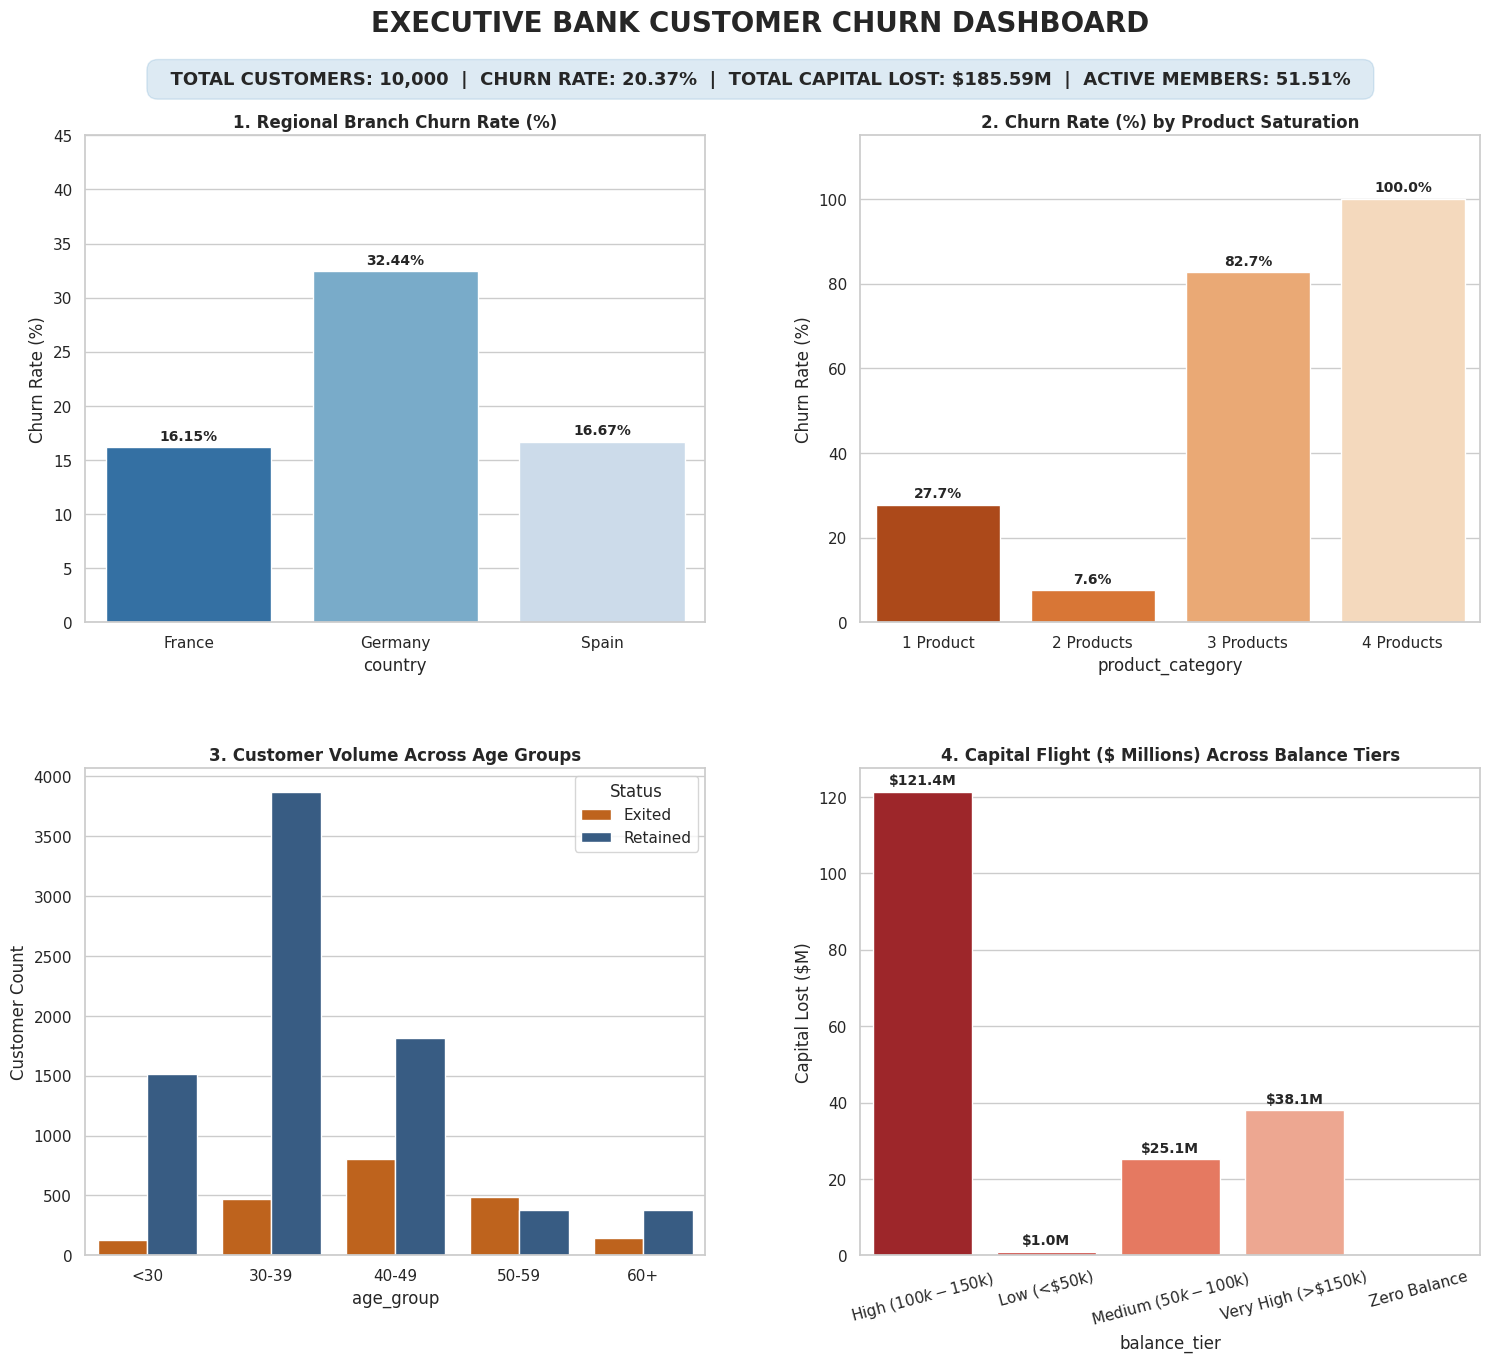

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Transformed_Bank_Customer_Churn.csv')

print("=== POINT 13: DASHBOARD DEVELOPMENT ===")

fig = plt.figure(figsize=(18, 14))
fig.suptitle('EXECUTIVE BANK CUSTOMER CHURN DASHBOARD', fontsize=20, fontweight='bold', y=0.97)

kpi_text = (
    f"  TOTAL CUSTOMERS: {len(df):,}  |  "
    f"CHURN RATE: {df['churn'].mean()*100:.2f}%  |  "
    f"TOTAL CAPITAL LOST: ${df['balance_lost'].sum()/1e6:.2f}M  |  "
    f"ACTIVE MEMBERS: {df['active_member'].mean()*100:.2f}%  "
)
fig.text(0.5, 0.92, kpi_text, ha='center', va='center', fontsize=13, 
         fontweight='bold', bbox=dict(boxstyle='round,pad=0.6', facecolor='#1f77b4', alpha=0.15, edgecolor='#1f77b4'))

gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25, top=0.88, bottom=0.08)

ax1 = fig.add_subplot(gs[0, 0])
geo_df = df.groupby('country')['churn'].mean().mul(100).reset_index()
sns.barplot(data=geo_df, x='country', y='churn', ax=ax1, palette='Blues_r')
ax1.set_title('1. Regional Branch Churn Rate (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_ylim(0, 45)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

ax2 = fig.add_subplot(gs[0, 1])
prod_df = df.groupby('product_category', observed=False)['churn'].mean().mul(100).reset_index()
sns.barplot(data=prod_df, x='product_category', y='churn', ax=ax2, palette='Oranges_r')
ax2.set_title('2. Churn Rate (%) by Product Saturation', fontsize=12, fontweight='bold')
ax2.set_ylabel('Churn Rate (%)')
ax2.set_ylim(0, 115)
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

ax3 = fig.add_subplot(gs[1, 0])
age_order = ['<30', '30-39', '40-49', '50-59', '60+']
sns.countplot(data=df, x='age_group', hue='churn_label', order=age_order, ax=ax3, palette={'Retained': '#2b5c8f', 'Exited': '#d95f02'})
ax3.set_title('3. Customer Volume Across Age Groups', fontsize=12, fontweight='bold')
ax3.set_ylabel('Customer Count')
ax3.legend(title='Status')

ax4 = fig.add_subplot(gs[1, 1])
bal_df = df.groupby('balance_tier', observed=False)['balance_lost'].sum().div(1e6).reset_index()
sns.barplot(data=bal_df, x='balance_tier', y='balance_lost', ax=ax4, palette='Reds_r')
ax4.set_title('4. Capital Flight ($ Millions) Across Balance Tiers', fontsize=12, fontweight='bold')
ax4.set_ylabel('Capital Lost ($M)')
ax4.tick_params(axis='x', rotation=15)
for p in ax4.patches:
    if p.get_height() > 0:
        ax4.annotate(f'${p.get_height():.1f}M', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

dashboard_output = 'Point13_Executive_Dashboard.png'
plt.savefig(dashboard_output, dpi=300, bbox_inches='tight')
plt.show()